# E-Commerce Customer Churn: Risk Signals and Past Investment

This notebook uses exploratory data analysis to compare churn across two areas:

1. **Five risk signals** related to customer experience and disengagement.
2. **Past relationship investment** based on spending, purchases, and customer tenure.

The final heatmap combines both areas. `churn_flag` is the target: 1 means churned and 0 means active. The analysis shows associations, not causes.

**Dataset source:** [E-Commerce Customer Churn Dataset](https://www.kaggle.com/datasets/datascikhan/e-commerce-customer-churn-2026/data)

## 1. Setup and Data

The dataset page describes 50,000 records and 48 columns. We load the raw CSV and use the numeric `churn_flag` to calculate churn rates.

In [31]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [32]:
# TODO: change to the clean datapath
data = pd.read_csv('../data/cleaned/customer_churn_final.csv')
data.head()

,customer_id,churn_flag,customer_segment,customer_age_months,satisfaction_score,engagement_level,support_tickets,support_interactions,returns_count,days_since_last_purchase,purchase_recency_group,customer_lifetime_value_usd,total_spend_usd,avg_order_value_usd,num_purchases,churn_reason,churn_revenue_impact_usd,customer_country
0,CUST-020712,1,Consumer,33,3,Low,0,1,9,35,31-60 days,29849.63,25878.37,892.36,29,Found Alternative,10351.348,Australia
1,CUST-044206,0,Small Business,55,2,High,6,1,3,3,0-30 days,30007.71,25992.52,1039.70,25,Not Applicable,0.000,Saudi Arabia
2,CUST-024093,0,Small Business,45,5,High,7,7,7,158,91-180 days,51527.18,45248.32,9049.66,5,Not Applicable,0.000,Mexico
3,CUST-037777,0,Enterprise,7,5,Medium,8,1,3,46,31-60 days,39139.58,31902.68,1329.28,24,Not Applicable,0.000,Saudi Arabia
4,CUST-016248,1,Premium,12,1,High,15,1,4,124,91-180 days,34506.94,35530.22,755.96,47,Poor Customer Service,14212.088,Pakistan


## 2. Five Risk Signals

We first explore five columns related to **experience friction and disengagement**. For each column, we calculate the mean of `churn_flag` within each group. This mean is the churn rate.

### 2.1 Satisfaction Level

- **Column:** `satisfaction_level` is the customer's qualitative satisfaction category.
- **Processing:** We order the levels from Very Satisfied to Very Dissatisfied and compare each group's churn rate with the overall rate.
- **Meaning:** Lower satisfaction may be an early sign of a poor customer experience.

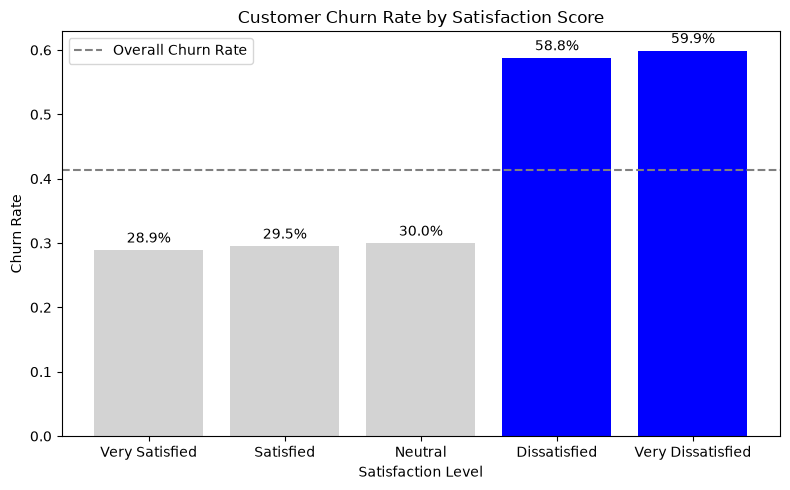

In [33]:
# Churn rate by satisfaction score

satisfaction_order = [5, 4, 3, 2, 1]

satisfaction_labels = [
    'Very Satisfied',
    'Satisfied',
    'Neutral',
    'Dissatisfied',
    'Very Dissatisfied'
]

satisfaction_colors = [
    'lightgray', 'lightgray', 'lightgray', 'blue', 'blue'
]

satisfaction_churn_rate = (
    data.groupby('satisfaction_score')['churn_flag']
    .mean()
    .reindex(satisfaction_order)
)

overall_churn_rate = data['churn_flag'].mean()

plt.figure(figsize=(8, 5))

bars = plt.bar(
    satisfaction_labels,
    satisfaction_churn_rate.values,
    color=satisfaction_colors
)

plt.bar_label(
    bars,
    labels=[f'{value:.1%}' for value in satisfaction_churn_rate.values],
    padding=3
)

plt.axhline(
    y=overall_churn_rate,
    color='gray',
    linestyle='--',
    label='Overall Churn Rate'
)

plt.title('Customer Churn Rate by Satisfaction Score')
plt.xlabel('Satisfaction Level')
plt.ylabel('Churn Rate')

plt.legend()
plt.tight_layout()
plt.show()

### 2.2 Engagement Level

- **Column:** `engagement_level` shows the customer's platform activity level.
- **Processing:** We order the categories from High to Low and calculate churn rate for each group.
- **Meaning:** Low engagement may show that a customer is becoming less active.

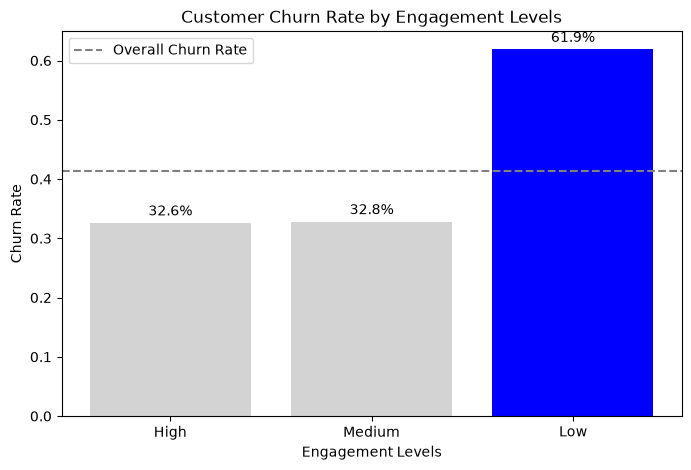

In [34]:
engagement_order = ['High', 'Medium', 'Low']
engagement_colors = ['lightgray', 'lightgray', 'blue']

engagement_churn_rate = (
    data.groupby('engagement_level')['churn_flag']
    .mean()
    .reindex(engagement_order)
)

overall_churn_rate = data['churn_flag'].mean()

plt.figure(figsize=(8, 5))

bars = plt.bar(
    engagement_churn_rate.index,
    engagement_churn_rate.values,
    color=engagement_colors
)

plt.bar_label(
    bars,
    labels=[f'{value:.1%}' for value in engagement_churn_rate.values],
    padding=3
)

plt.axhline(
    y=overall_churn_rate,
    color='gray',
    linestyle='--',
    label='Overall Churn Rate'
)

plt.title('Customer Churn Rate by Engagement Levels')
plt.xlabel('Engagement Levels')
plt.ylabel('Churn Rate')
plt.legend()
plt.show()


### 2.3 Support Tickets

- **Column:** `support_tickets` is the total number of support tickets raised by a customer.
- **Processing:** We group the counts into five ranges and calculate churn rate for each range.
- **Meaning:** More tickets may represent repeated service problems or customer friction.

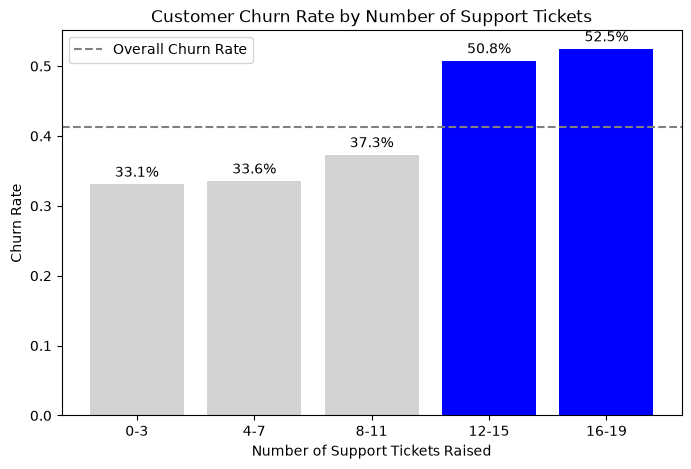

In [35]:
# Get to know the range of support tickets and cut them into groups based on the range
data['support_tickets'].describe()

data['support_ticket_group'] = pd.cut(
    data['support_tickets'],
    bins=[-1, 3, 7, 11, 15, 19],
    labels=['0-3', '4-7', '8-11', '12-15', '16-19']
)

tickets_order = ['0-3', '4-7', '8-11', '12-15', '16-19']

# Support ticket groups & churn rate
tickets_churn_rate = (
    data.groupby('support_ticket_group')['churn_flag']
    .mean()
    .reindex(tickets_order)
)

overall_churn_rate = data['churn_flag'].mean()
tickets_colors = ['lightgray', 'lightgray', 'lightgray', 'blue', 'blue']

plt.figure(figsize=(8, 5))

bars = plt.bar(
    tickets_churn_rate.index,
    tickets_churn_rate.values,
    color=tickets_colors
)

plt.bar_label(
    bars,
    labels=[f'{value:.1%}' for value in tickets_churn_rate.values],
    padding=3
)

plt.axhline(
    y=overall_churn_rate,
    color='gray',
    linestyle='--',
    label='Overall Churn Rate'
)

plt.title('Customer Churn Rate by Number of Support Tickets')
plt.xlabel('Number of Support Tickets Raised')
plt.ylabel('Churn Rate')
plt.legend()
plt.show()


### 2.4 Returns Count

- **Column:** `returns_count` is the total number of product returns.
- **Processing:** We group the counts into five ranges and calculate churn rate for each range.
- **Meaning:** More returns may represent problems with products or the purchase experience.

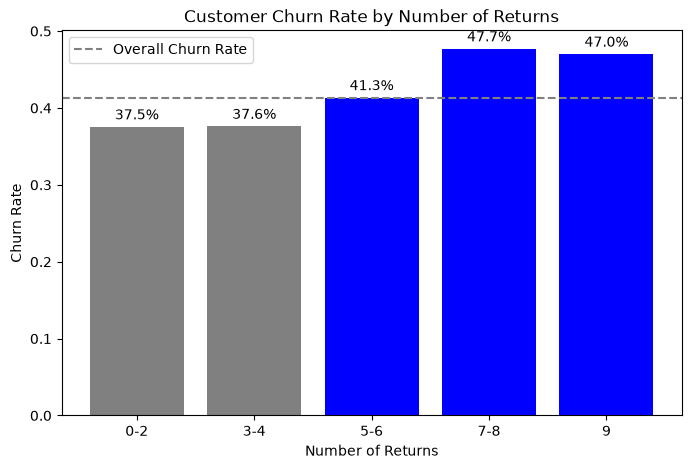

In [36]:
# Create return groups
data['return_group'] = pd.cut(
    data['returns_count'],
    bins=[-1, 2, 4, 6, 8, 9],
    labels=['0-2', '3-4', '5-6', '7-8', '9']
)

returns_order = ['0-2', '3-4', '5-6', '7-8', '9']

# Churn rate for each return group
returns_churn_rate = (
    data.groupby('return_group')['churn_flag']
    .mean()
    .reindex(returns_order)
)


overall_churn_rate = data['churn_flag'].mean()

returns_colors = ['gray', 'gray', 'blue', 'blue', 'blue']

plt.figure(figsize=(8, 5))

bars = plt.bar(
    returns_churn_rate.index,
    returns_churn_rate.values,
    color=returns_colors
)

plt.bar_label(
    bars,
    labels=[f'{value:.1%}' for value in returns_churn_rate.values],
    padding=3
)

plt.axhline(
    y=overall_churn_rate,
    color='gray',
    linestyle='--',
    label='Overall Churn Rate'
)

plt.title('Customer Churn Rate by Number of Returns')
plt.xlabel('Number of Returns')
plt.ylabel('Churn Rate')

plt.legend()
plt.show()

### 2.5 Days Since Last Purchase

- **Column:** `days_since_last_purchase` measures the number of days since the customer's last order.
- **Processing:** We divide recency into five time ranges and calculate churn rate for each range.
- **Meaning:** A longer gap may show that the customer is becoming inactive.

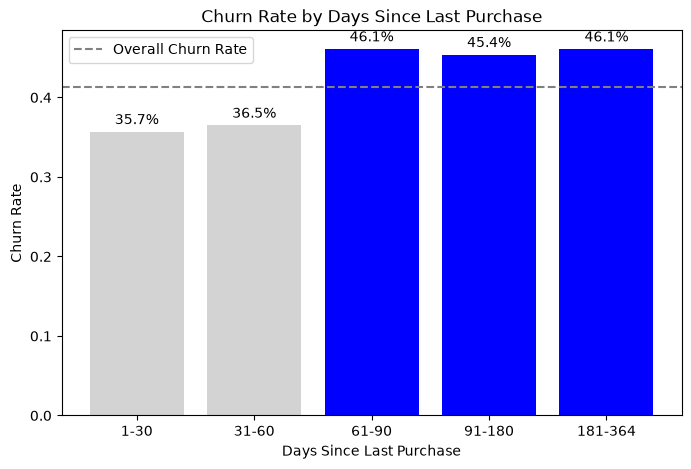

In [37]:
data['days_purchase_group'] = pd.cut(
    data['days_since_last_purchase'],
    bins=[0, 30, 60, 90, 180, 364],
    labels=['1-30', '31-60', '61-90', '91-180', '181-364']
)

days_order = ['1-30', '31-60', '61-90', '91-180', '181-364']

# Churn rate for each group
days_churn_rate = (
    data.groupby('days_purchase_group')['churn_flag']
    .mean()
    .reindex(days_order)
)

# Overall churn rate
overall_churn_rate = data['churn_flag'].mean()

# Plot
plt.figure(figsize=(8, 5))

days_colors = [
    'lightgray',
    'lightgray',
    'blue',
    'blue',
    'blue'
]

bars = plt.bar(
    days_churn_rate.index,
    days_churn_rate.values,
    color=days_colors
)


plt.bar_label(
    bars,
    labels=[f'{value:.1%}' for value in days_churn_rate.values],
    padding=3
)


plt.axhline(
    y=overall_churn_rate,
    color='gray',
    linestyle='--',
    label='Overall Churn Rate'
)

plt.title('Churn Rate by Days Since Last Purchase')
plt.xlabel('Days Since Last Purchase')
plt.ylabel('Churn Rate')

plt.legend()
plt.show()


### 2.6 Create the Risk Signal Count

Each record receives one point for each condition:

- `satisfaction_score <= 2`
- `engagement_level == Low`
- `support_tickets >= 12`
- `returns_count >= 5`
- `days_since_last_purchase >= 61`

We add the five binary signals to create `risk_signal_count`, ranging from 0 to 5. The signals have equal weight and are used for exploratory analysis.

In [38]:


data["low_satisfaction_signal"] = (
    data["satisfaction_score"] <= 2
).astype(int)

data["low_engagement_signal"] = (
    data["engagement_level"] == "Low"
).astype(int)

data["high_support_signal"] = (
    data["support_tickets"] >= 12
).astype(int)

data["high_returns_signal"] = (
    data["returns_count"] >= 5
).astype(int)

data["purchase_inactivity_signal"] = (
    data["days_since_last_purchase"] >= 61
).astype(int)


# Add the five signals together
risk_signal_columns = [
    "low_satisfaction_signal",
    "low_engagement_signal",
    "high_support_signal",
    "high_returns_signal",
    "purchase_inactivity_signal"
]

data["risk_signal_count"] = (
    data[risk_signal_columns].sum(axis=1)
)


## 3. Past Relationship Investment

This section summarizes how much history a customer has built with the platform.

- `total_spend_usd`: cumulative customer spending.
- `num_purchases`: total completed purchases.
- `customer_age_months`: length of the customer relationship in months, not the customer's age.

The three columns use different scales, so we convert each one to a percentile rank. We average the three percentiles to create `relationship_investment_score`, then divide the score into five equal-sized levels from Very Low to Very High.

In [39]:

investment_features = [
    "total_spend_usd",
    "num_purchases",
    "customer_age_months"
]

percentile_cols = []

for col in investment_features:
    new_col = col + "_percentile"

    data[new_col] = (
        data[col].rank(pct=True) * 100
    )

    percentile_cols.append(new_col)


# Average the three percentile rankings
data["relationship_investment_score"] = (
    data[percentile_cols].mean(axis=1)
)


# Divide customers into five investment levels
investment_order = [
    "Very Low",
    "Low",
    "Medium",
    "High",
    "Very High"
]

data["investment_level"] = pd.qcut(
    data["relationship_investment_score"],
    q=5,
    labels=investment_order
)



## 4. Combined Heatmap

The heatmap combines both parts of the analysis:

- **Rows:** number of risk signals, from 0 to 5.
- **Columns:** past investment level, from Very Low to Very High.
- **Color and cell value:** churn rate for each combination.

This layout lets us compare changes across risk signals and past investment at the same time.

In [40]:
# --------------------------------------------------
#  Calculate churn rates for the heatmap
# --------------------------------------------------

heatmap_data = data.pivot_table(
    index="risk_signal_count",
    columns="investment_level",
    values="churn_flag",
    aggfunc="mean",
    observed=False
)

heatmap_data = heatmap_data.reindex(
    index=range(6),
    columns=investment_order
)

heatmap_data = heatmap_data * 100


### Overall Rates and Labels

We also calculate the overall churn rate for every investment level and every risk-signal count. These values provide context around the heatmap.

In [41]:
# --------------------------------------------------
#  Calculate overall churn rates for the labels
# --------------------------------------------------

investment_overall = (
    data.groupby(
        "investment_level",
        observed=False
    )["churn_flag"]
    .mean()
    .reindex(investment_order)
    * 100
)

signal_overall = (
    data.groupby(
        "risk_signal_count"
    )["churn_flag"]
    .mean()
    .reindex(range(6))
    * 100
)


# Labels for the x-axis
x_labels = [
    f"{level}\nOverall: {investment_overall[level]:.1f}%"
    for level in investment_order
]


# Labels for the y-axis
y_labels = [
    f"{number} {'signal' if number == 1 else 'signals'}\n"
    f"Overall: {signal_overall[number]:.1f}%"
    for number in range(6)
]


# Add percentage signs inside the heatmap
heatmap_labels = (
    heatmap_data.round(1).astype(str) + "%"
)


### Final Visualization

The final chart shows a strong vertical color change as the number of risk signals increases, while the colors remain similar across investment levels.

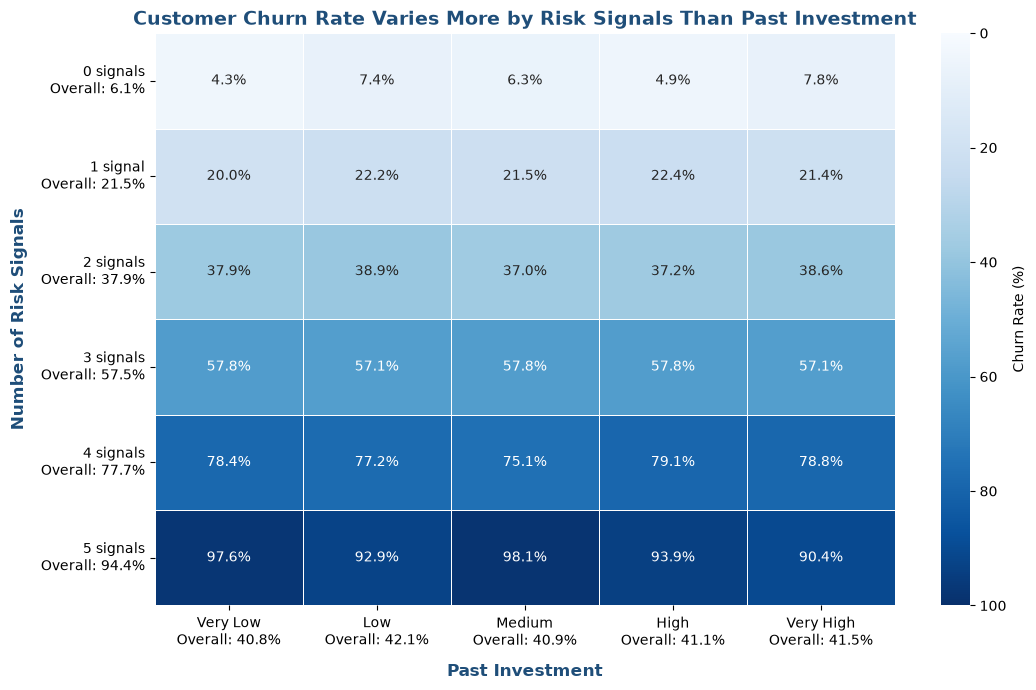

In [42]:
# --------------------------------------------------
# 5. Create the heatmap
# --------------------------------------------------

plt.figure(figsize=(11, 7))

ax = sns.heatmap(
    heatmap_data,
    annot=heatmap_labels,
    fmt="",
    cmap="Blues",
    vmin=0,
    vmax=100,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={
        "label": "Churn Rate (%)"
    }
)
ax.collections[0].colorbar.ax.invert_yaxis()

ax.set_xticklabels(
    x_labels,
    rotation=0
)

ax.set_yticklabels(
    y_labels,
    rotation=0
)
label_color = "#1F4E79"

plt.title(
    "Customer Churn Rate Varies More by Risk Signals Than Past Investment",
    fontsize=14,
    fontweight="bold",
    color=label_color,

)

plt.xlabel(
    "Past Investment",
    fontsize=12,
    fontweight="bold",
    color=label_color,
    labelpad=10
)

plt.ylabel(
    "Number of Risk Signals",
    fontsize=12,
    fontweight="bold",
    color=label_color,
    labelpad=10
)

plt.tight_layout()
plt.show()

## 5. Main Finding and Limitation

In this dataset, churn varies much more across the number of risk signals than across past investment levels. Past spending and customer history do not show the same clear pattern as experience friction and disengagement.

This is a record-level descriptive analysis. It does not show that the five signals cause churn.